# Visualize results

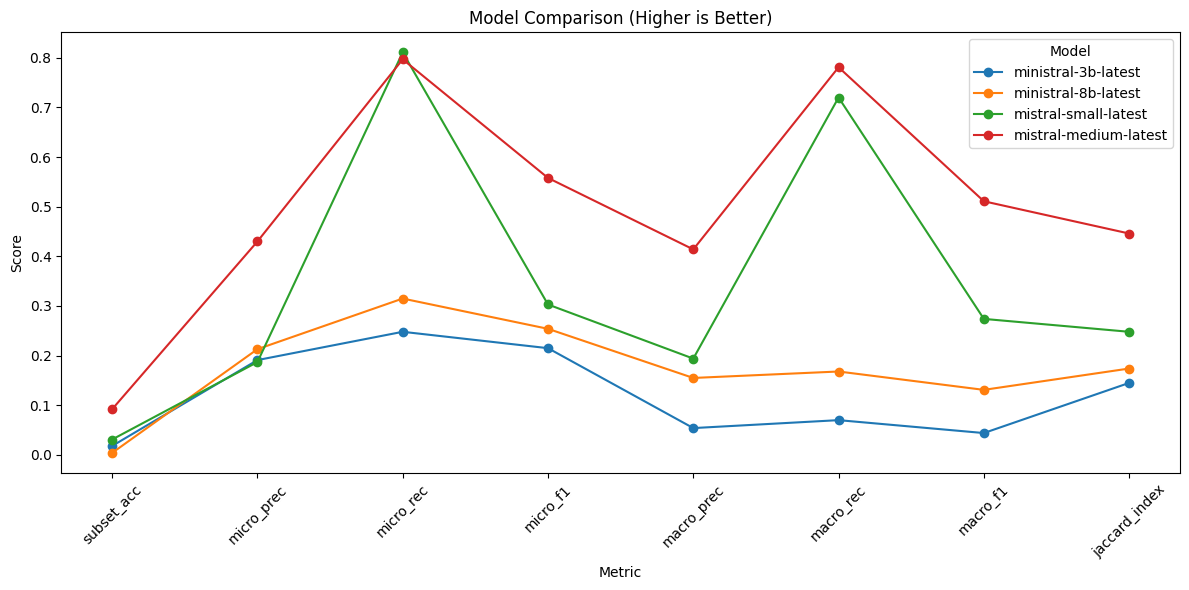

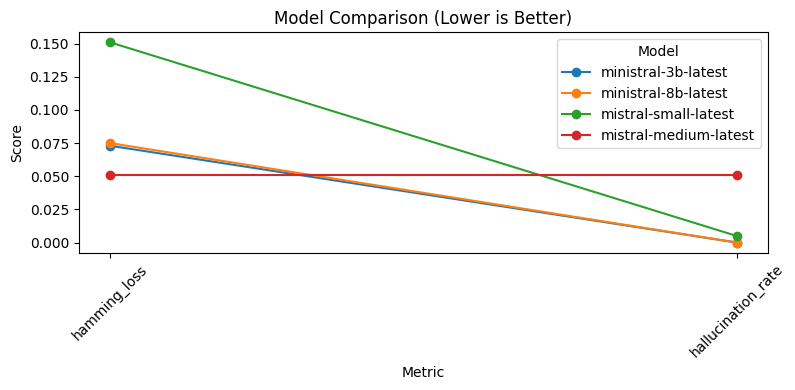

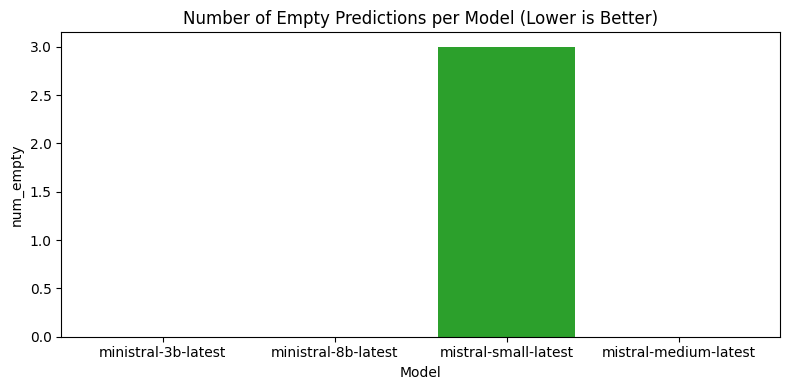

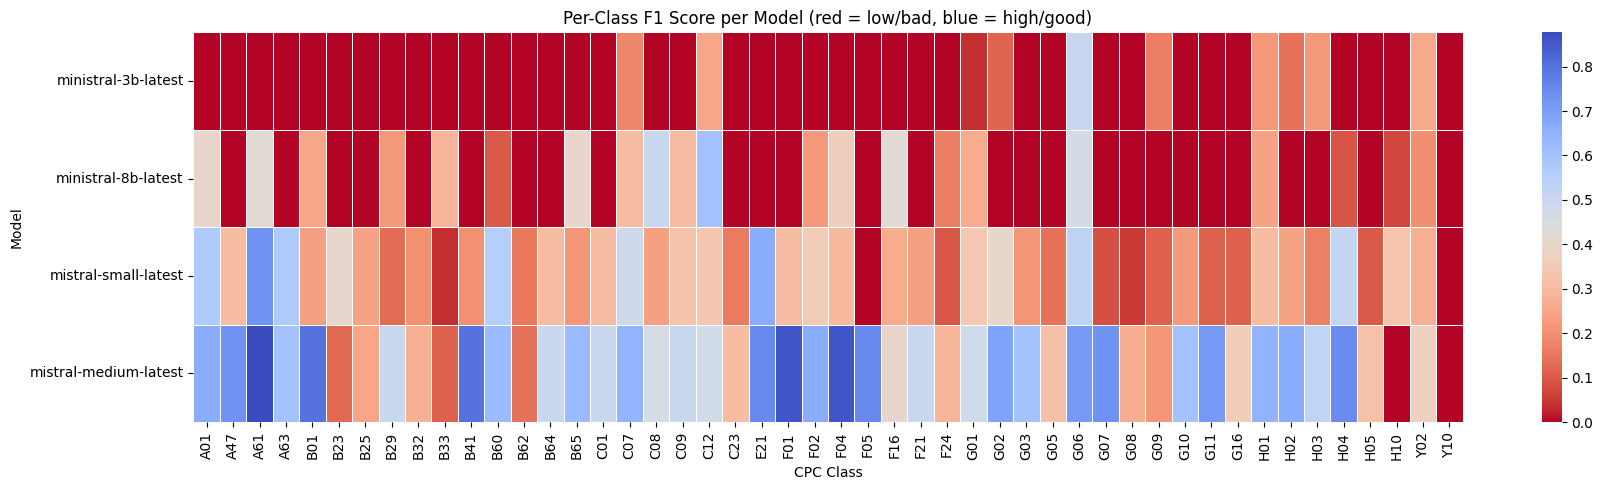

In [4]:
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("metrics.csv")

# Metrics where higher is better
higher_better_metrics = [
    "subset_acc",
    "micro_prec",
    "micro_rec",
    "micro_f1",
    "macro_prec",
    "macro_rec",
    "macro_f1",
    "jaccard_index",
]

# Chart 1: Higher is better
plt.figure(figsize=(12, 6))
for model in df["model"]:
    plt.plot(
        higher_better_metrics,
        df[df["model"] == model][higher_better_metrics].values[0],
        marker="o",
        label=model,
    )
plt.xlabel("Metric")
plt.ylabel("Score")
plt.title("Model Comparison (Higher is Better)")
plt.legend(title="Model")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Chart 2: Plot hamming_loss and hallucination_rate (lower is better)
plt.figure(figsize=(8, 4))
for model in df["model"]:
    plt.plot(
        ["hamming_loss", "hallucination_rate"],
        df[df["model"] == model][["hamming_loss", "hallucination_rate"]].values[0],
        marker="o",
        label=model,
    )
plt.xlabel("Metric")
plt.ylabel("Score")
plt.title("Model Comparison (Lower is Better)")
plt.legend(title="Model")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Chart 3: Plot num_empty separately
plt.figure(figsize=(8, 4))
for model in df["model"]:
    plt.bar(model, df[df["model"] == model]["num_empty"].values[0])
plt.xlabel("Model")
plt.ylabel("num_empty")
plt.title("Number of Empty Predictions per Model (Lower is Better)")
plt.tight_layout()
plt.show()

# Chart 4: Per-class F1 score
class_f1_matrix = pd.DataFrame(
    [ast.literal_eval(row["class_f1"]) for _, row in df.iterrows()], index=df["model"]
)

plt.figure(figsize=(18, 5))
sns.heatmap(
    class_f1_matrix.astype(float),
    cmap="coolwarm_r",  # The "_r" reverses the colormap
    annot=False,
    linewidths=0.5,
)
plt.title("Per-Class F1 Score per Model (red = low/bad, blue = high/good)")
plt.xlabel("CPC Class")
plt.ylabel("Model")
plt.tight_layout()
plt.show()